# Comparing X-MACE Latent Spaces With PCA

This notebook trains three equivalent 16D autoencoder models and compares how their latent spaces change with **molecule type** and **level of theory**.

The comparisons are:

- Ethene 2e2o against propene 2e2o
- Propene 2e2o against propene 4e4o

Each model uses the same number of geometries and the same tunable hyperparameters. Generated figures are written to `nicer_tutorials/_outputs/04_pca/graphs/`.

## 1. Setup And Load Data

In [1]:
import os
import time
from pathlib import Path

TUTORIAL_ROOT = Path(os.getcwd())
DATA_DIR = TUTORIAL_ROOT / "data" / "xyz"
OUTPUT_DIR = TUTORIAL_ROOT / "_outputs" / "04_pca"
GRAPH_DIR = OUTPUT_DIR / "graphs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

ETHENE_22_FILE = DATA_DIR / "A01_ethene_grid_static.xyz"
PROPENE_22_FILE = DATA_DIR / "A02_propene_grid_static.xyz"
PROPENE_44_FILE = DATA_DIR / "casscf_44_propene_full.xyz"

# Keep matplotlib cache files inside the ignored output folder.
MPLCONFIGDIR = OUTPUT_DIR / "matplotlib_cache"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import numpy as np
import ase.io
import torch
from e3nn import o3
import matplotlib.pyplot as plt

from mace import data, modules, tools
from mace.tools import torch_geometric

DEVICE = torch.device("cpu")

R_MAX = 5.0
BATCH_SIZE = 16
VALID_FRACTION = 0.2
SEED = 123
LATENT_DIM = 16
N_ENERGIES = 3
MAX_EPOCHS = 50

The 4e4o propene dataset is the smallest dataset, so its size defines the common number of geometries. The first 500 geometries in the two propene files describe the same structures in the same order.

In [2]:
atoms_propene_44 = ase.io.read(str(PROPENE_44_FILE), index=":")
N_GEOMETRIES = len(atoms_propene_44)

atoms_ethene_22 = ase.io.read(str(ETHENE_22_FILE), index=f":{N_GEOMETRIES}")
atoms_propene_22 = ase.io.read(str(PROPENE_22_FILE), index=f":{N_GEOMETRIES}")

print(f"Common number of geometries: {N_GEOMETRIES}")
print(f"Ethene 2e2o:  {len(atoms_ethene_22)}")
print(f"Propene 2e2o: {len(atoms_propene_22)}")
print(f"Propene 4e4o: {len(atoms_propene_44)}")

Common number of geometries: 500
Ethene 2e2o:  500
Propene 2e2o: 500
Propene 4e4o: 500


## 2. Prepare And Train Minimal Example Models

`train_autoencoder` builds a fresh model for one atoms list. The random seed, split, architecture, optimizer, and number of epochs are reset for every call. Atomic-energy baselines and average neighbour counts are calculated separately because they depend on the dataset.

In [3]:
def train_autoencoder(atoms_list):
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    configs = data.config_from_atoms_list(
        atoms_list,
        energy_key="REF_energy",
        forces_key="REF_forces",
        config_type_weights={"Default": 1.0},
    )

    train_configs, valid_configs = data.random_train_valid_split(
        configs,
        valid_fraction=VALID_FRACTION,
        seed=SEED,
        work_dir=str(OUTPUT_DIR),
    )

    z_table = tools.get_atomic_number_table_from_zs(
        z for config in configs for z in config.atomic_numbers
    )
    atomic_energies_dict = data.compute_average_E0s(train_configs, z_table)
    atomic_energies = np.array(
        [atomic_energies_dict[z] for z in z_table.zs], dtype=np.float64
    )

    train_set = [
        data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
        for config in train_configs
    ]
    valid_set = [
        data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
        for config in valid_configs
    ]

    train_loader = torch_geometric.dataloader.DataLoader(
        train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
    )
    valid_loader = torch_geometric.dataloader.DataLoader(
        valid_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
    )

    avg_num_neighbors = modules.compute_avg_num_neighbors(train_loader)

    model = modules.AutoencoderExcitedMACE(
        r_max=R_MAX,
        num_bessel=4,
        num_polynomial_cutoff=3,
        num_permutational_invariant=LATENT_DIM,
        n_energies=N_ENERGIES,
        max_ell=2,
        interaction_cls=modules.interaction_classes["RealAgnosticResidualInteractionBlock"],
        interaction_cls_first=modules.interaction_classes["RealAgnosticResidualInteractionBlock"],
        num_interactions=1,
        num_elements=len(z_table),
        hidden_irreps=o3.Irreps("4x0e + 4x1o"),
        MLP_irreps=o3.Irreps("16x0e"),
        atomic_energies=atomic_energies,
        avg_num_neighbors=float(avg_num_neighbors),
        atomic_numbers=[int(z) for z in z_table.zs],
        correlation=1,
        gate=modules.gate_dict["silu"],
        radial_MLP=[32, 32],
        compute_nacs=False,
        compute_socs=False,
        nac_num=0,
        soc_num=0,
    ).to(DEVICE)

    loss_fn = modules.InvariantsWeightedEnergyForcesNacsDipoleLoss(
        energy_weight=1.0,
        forces_weight=5.0,
        dipoles_weight=0.0,
        nacs_weight=0.0,
        socs_weight=0.0,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=1.0e-3)

    def compute_batch_loss(batch, training):
        batch = batch.to(DEVICE)
        output = model(
            batch.to_dict(),
            training=training,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )

        centred_reference_energy = (
            batch["energy"] - output["e0s"] - output["pair_energy"]
        ).unsqueeze(-1)
        output["encoded_energy"] = model.perm_encoder(centred_reference_energy)
        output["decoded_energy"] = (
            model.perm_decoder(output["encoded_energy"])
            + output["e0s"]
            + output["pair_energy"]
        )
        return loss_fn(ref=batch, pred=output)

    for epoch in range(MAX_EPOCHS):
        epoch_start = time.time()
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss = compute_batch_loss(batch, training=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()
            train_losses.append(float(loss.detach().cpu()))

        model.eval()
        valid_losses = []
        for batch in valid_loader:
            loss = compute_batch_loss(batch, training=False)
            valid_losses.append(float(loss.detach().cpu()))

        train_loss = float(np.mean(train_losses))
        valid_loss = float(np.mean(valid_losses))
        seconds = time.time() - epoch_start
        print(
            f"Epoch {epoch + 1:03d} | train_loss={train_loss:.6f} | "
            f"valid_loss={valid_loss:.6f} | {seconds:.1f}s"
        )

    return model

In [4]:
print("Training ethene 2e2o")
model_ethene_22 = train_autoencoder(atoms_ethene_22)

print("\nTraining propene 2e2o")
model_propene_22 = train_autoencoder(atoms_propene_22)

print("\nTraining propene 4e4o")
model_propene_44 = train_autoencoder(atoms_propene_44)

Training ethene 2e2o


/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript typ

Epoch 001 | train_loss=158.836979 | valid_loss=179.234741 | 1.3s
Epoch 002 | train_loss=147.116586 | valid_loss=166.216893 | 0.7s
Epoch 003 | train_loss=129.611883 | valid_loss=144.470011 | 0.6s
Epoch 004 | train_loss=117.831406 | valid_loss=126.138859 | 0.6s
Epoch 005 | train_loss=107.276086 | valid_loss=110.268335 | 0.6s
Epoch 006 | train_loss=94.459086 | valid_loss=94.643629 | 0.6s
Epoch 007 | train_loss=75.363684 | valid_loss=80.315178 | 0.7s
Epoch 008 | train_loss=66.059811 | valid_loss=66.717885 | 0.7s
Epoch 009 | train_loss=55.918856 | valid_loss=61.774512 | 0.6s
Epoch 010 | train_loss=46.912824 | valid_loss=45.756266 | 0.6s
Epoch 011 | train_loss=39.675734 | valid_loss=43.474083 | 0.7s
Epoch 012 | train_loss=35.479815 | valid_loss=37.796837 | 0.6s
Epoch 013 | train_loss=33.916412 | valid_loss=33.540435 | 0.6s
Epoch 014 | train_loss=30.655590 | valid_loss=29.729146 | 0.6s
Epoch 015 | train_loss=28.318297 | valid_loss=27.496110 | 0.6s
Epoch 016 | train_loss=25.767352 | valid_loss

/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript typ

Epoch 001 | train_loss=115.097177 | valid_loss=88.703024 | 0.9s
Epoch 002 | train_loss=105.639983 | valid_loss=87.431583 | 0.8s
Epoch 003 | train_loss=103.488326 | valid_loss=84.561926 | 0.9s
Epoch 004 | train_loss=101.155031 | valid_loss=80.764947 | 0.9s
Epoch 005 | train_loss=95.922446 | valid_loss=78.763689 | 1.0s
Epoch 006 | train_loss=94.059503 | valid_loss=77.369979 | 0.8s
Epoch 007 | train_loss=92.474605 | valid_loss=75.989366 | 0.8s
Epoch 008 | train_loss=87.758174 | valid_loss=70.598021 | 0.8s
Epoch 009 | train_loss=74.333882 | valid_loss=53.584813 | 0.8s
Epoch 010 | train_loss=51.061767 | valid_loss=40.011797 | 0.8s
Epoch 011 | train_loss=40.669089 | valid_loss=39.043876 | 0.8s
Epoch 012 | train_loss=35.442454 | valid_loss=33.802405 | 0.8s
Epoch 013 | train_loss=30.928475 | valid_loss=30.753412 | 0.9s
Epoch 014 | train_loss=28.669281 | valid_loss=28.425841 | 0.8s
Epoch 015 | train_loss=26.701760 | valid_loss=27.812200 | 0.8s
Epoch 016 | train_loss=25.015713 | valid_loss=26.15

/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript typ

Epoch 001 | train_loss=98.522940 | valid_loss=69.151287 | 0.8s
Epoch 002 | train_loss=92.095204 | valid_loss=67.303159 | 0.8s
Epoch 003 | train_loss=90.388532 | valid_loss=64.935148 | 0.8s
Epoch 004 | train_loss=86.956088 | valid_loss=64.230455 | 0.8s
Epoch 005 | train_loss=84.840998 | valid_loss=63.639429 | 0.8s
Epoch 006 | train_loss=82.168030 | valid_loss=61.079790 | 0.8s
Epoch 007 | train_loss=77.917778 | valid_loss=57.787541 | 0.8s
Epoch 008 | train_loss=70.795873 | valid_loss=50.294482 | 0.8s
Epoch 009 | train_loss=60.020631 | valid_loss=43.645907 | 0.8s
Epoch 010 | train_loss=51.134041 | valid_loss=36.745912 | 0.8s
Epoch 011 | train_loss=41.846012 | valid_loss=27.212287 | 0.8s
Epoch 012 | train_loss=28.440848 | valid_loss=17.646095 | 0.8s
Epoch 013 | train_loss=15.965357 | valid_loss=12.128325 | 0.8s
Epoch 014 | train_loss=11.936874 | valid_loss=9.905780 | 0.8s
Epoch 015 | train_loss=11.347429 | valid_loss=11.022307 | 0.8s
Epoch 016 | train_loss=12.658073 | valid_loss=10.089815 

## 3. Extract The 16D Latent Spaces

The model does not store its training data, so the extraction function receives both the trained model and the atoms to evaluate.

This X-MACE fork currently calculates forces even when `compute_force=False` is requested. Therefore, the function keeps gradient tracking enabled, omits that ineffective argument, and immediately detaches only the latent vectors.

In [5]:
def extract_latent_space(model, atoms_list):
    configs = data.config_from_atoms_list(
        atoms_list,
        energy_key="REF_energy",
        forces_key="REF_forces",
        config_type_weights={"Default": 1.0},
    )

    atomic_numbers = [int(z) for z in model.atomic_numbers.detach().cpu().tolist()]
    z_table = tools.AtomicNumberTable(atomic_numbers)
    cutoff = float(model.r_max.detach().cpu())

    dataset = [
        data.AtomicData.from_config(config, z_table=z_table, cutoff=cutoff)
        for config in configs
    ]
    loader = torch_geometric.dataloader.DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
    )

    model.eval()
    latent_batches = []

    # Force evaluation inside this fork requires PyTorch autograd to remain enabled.
    with torch.enable_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            output = model(
                batch.to_dict(),
                training=False,
                compute_virials=False,
                compute_stress=False,
            )
            latent_batches.append(output["invariant_vals"].detach().cpu().numpy())
            del output

    latent_vectors = np.concatenate(latent_batches, axis=0)
    expected_shape = (len(atoms_list), LATENT_DIM)
    assert latent_vectors.shape == expected_shape, (latent_vectors.shape, expected_shape)
    return latent_vectors

In [6]:
latent_ethene_22 = extract_latent_space(model_ethene_22, atoms_ethene_22)
latent_propene_22 = extract_latent_space(model_propene_22, atoms_propene_22)
latent_propene_44 = extract_latent_space(model_propene_44, atoms_propene_44)

print("Ethene 2e2o latent shape: ", latent_ethene_22.shape)
print("Propene 2e2o latent shape:", latent_propene_22.shape)
print("Propene 4e4o latent shape:", latent_propene_44.shape)

Ethene 2e2o latent shape:  (500, 16)
Propene 2e2o latent shape: (500, 16)
Propene 4e4o latent shape: (500, 16)


## 4. PCA Comparisons

Visualise how the latent spaces look like using PCA. First by doing PCA on the 3 datsets independently. This doesnt really offer any physically meaningful interpretations it gives a rough idea how what kind of information is being represented. 



In [18]:
def compute_shared_pca_2d(latent_a, latent_b):
    if latent_a.ndim != 2 or latent_b.ndim != 2:
        raise ValueError("Both latent arrays must have shape [n_geometries, latent_dim].")
    if latent_a.shape[1] != latent_b.shape[1]:
        raise ValueError("Both latent arrays must have the same latent dimension.")

    combined_latent = np.concatenate([latent_a, latent_b], axis=0)
    shared_mean = combined_latent.mean(axis=0, keepdims=True)
    combined_centered = combined_latent - shared_mean

    _, singular_values, components = np.linalg.svd(
        combined_centered, full_matrices=False
    )
    principal_components = components[:2]

    projected_a = (latent_a - shared_mean) @ principal_components.T
    projected_b = (latent_b - shared_mean) @ principal_components.T

    variance = singular_values**2 / (combined_centered.shape[0] - 1)
    explained_variance_ratio = variance / variance.sum()
    return projected_a, projected_b, explained_variance_ratio


def compute_independent_pca_2d(latent_vectors):
    latent_centered = latent_vectors - latent_vectors.mean(axis=0, keepdims=True)
    _, singular_values, components = np.linalg.svd(
        latent_centered, full_matrices=False
    )
    projected = latent_centered @ components[:2].T

    variance = singular_values**2 / (latent_centered.shape[0] - 1)
    explained_variance_ratio = variance / variance.sum()
    return projected, explained_variance_ratio


def relative_ground_state_energy(atoms_list):
    ground_state_energy = np.array(
        [np.asarray(atoms.info["REF_energy"]).reshape(-1)[0] for atoms in atoms_list]
    )
    return ground_state_energy - ground_state_energy.min()


def plot_projected_pca(ax, pca_2d, atoms_list, title, explained_variance_ratio):
    relative_energy = relative_ground_state_energy(atoms_list)

    scatter = ax.scatter(
        pca_2d[:, 0],
        pca_2d[:, 1],
        c=relative_energy,
        s=14,
        cmap="viridis",
        alpha=0.8,
        linewidths=0,
    )
    ax.set_xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    colorbar = ax.figure.colorbar(scatter, ax=ax)
    colorbar.set_label(r"Relative ground-state energy $E_0 - E_{0,\min}$ / eV")


def set_shared_pca_limits(axes, projected_a, projected_b):
    combined_projection = np.concatenate([projected_a, projected_b], axis=0)
    x_min, y_min = combined_projection.min(axis=0)
    x_max, y_max = combined_projection.max(axis=0)
    x_padding = max(0.05 * (x_max - x_min), 1.0e-8)
    y_padding = max(0.05 * (y_max - y_min), 1.0e-8)

    for ax in axes:
        ax.set_xlim(x_min - x_padding, x_max + x_padding)
        ax.set_ylim(y_min - y_padding, y_max + y_padding)

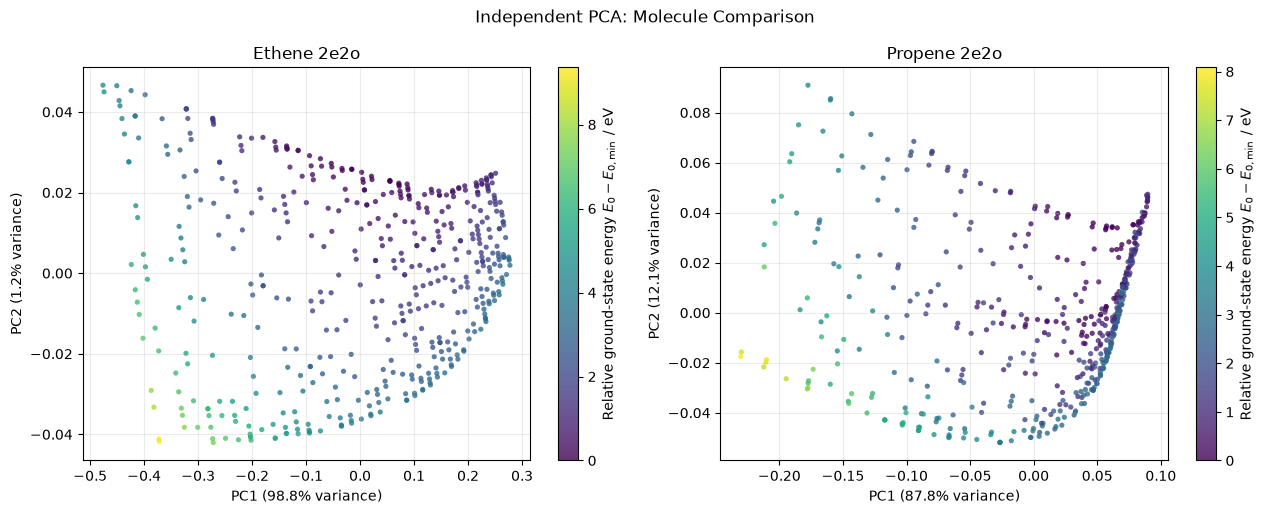

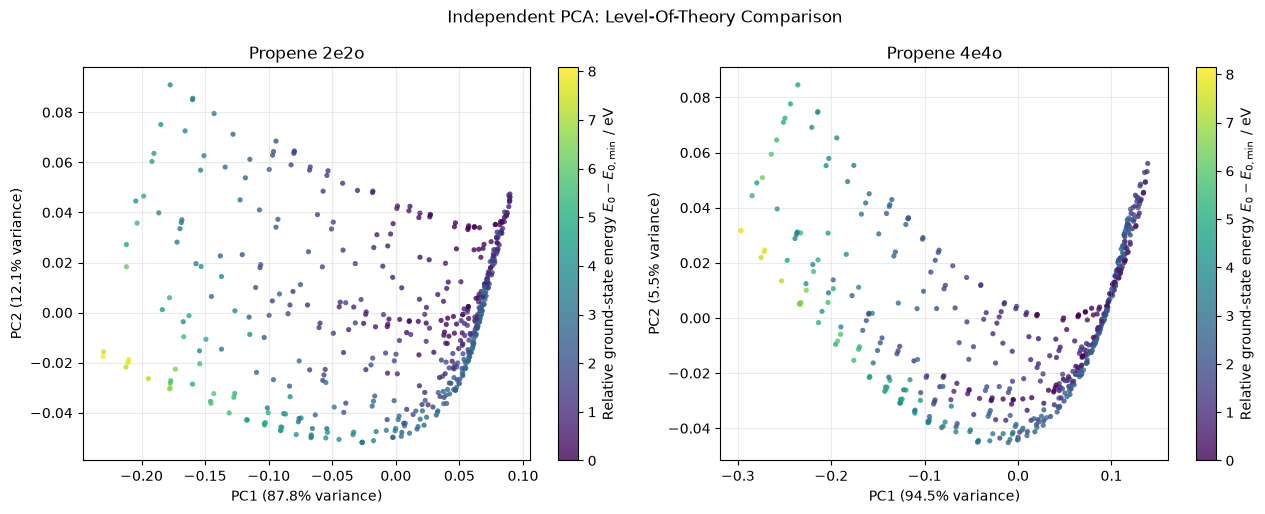

In [19]:
pca_ethene_22_independent, variance_ethene_22_independent = (
    compute_independent_pca_2d(latent_ethene_22)
)
pca_propene_22_independent, variance_propene_22_independent = (
    compute_independent_pca_2d(latent_propene_22)
)
pca_propene_44_independent, variance_propene_44_independent = (
    compute_independent_pca_2d(latent_propene_44)
)

assert pca_ethene_22_independent.shape == (N_GEOMETRIES, 2)
assert pca_propene_22_independent.shape == (N_GEOMETRIES, 2)
assert pca_propene_44_independent.shape == (N_GEOMETRIES, 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_projected_pca(
    axes[0],
    pca_ethene_22_independent,
    atoms_ethene_22,
    "Ethene 2e2o",
    variance_ethene_22_independent,
)
plot_projected_pca(
    axes[1],
    pca_propene_22_independent,
    atoms_propene_22,
    "Propene 2e2o",
    variance_propene_22_independent,
)
fig.suptitle("Independent PCA: Molecule Comparison")
fig.tight_layout()
fig.savefig(GRAPH_DIR / "pca_independent_molecule_comparison.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_projected_pca(
    axes[0],
    pca_propene_22_independent,
    atoms_propene_22,
    "Propene 2e2o",
    variance_propene_22_independent,
)
plot_projected_pca(
    axes[1],
    pca_propene_44_independent,
    atoms_propene_44,
    "Propene 4e4o",
    variance_propene_44_independent,
)
fig.suptitle("Independent PCA: Level-Of-Theory Comparison")
fig.tight_layout()
fig.savefig(
    GRAPH_DIR / "pca_independent_level_of_theory_comparison.png", dpi=150
)
plt.show()

The above plots at least seem to indicate that the latent space is quite low dimensional. Because about 90+% of the variance is captured along PC1 already. There seems to be some interesting shapes but tbh dk yet what it means physically also 

## 4.2 Indpendent PCA axis
The next part tries to do the same thing but fix the PCA axis to be the same for abit more meaningful comparisons? So ie before we were just looking at independent axis that were optimised for each dataset
Here instead try
1) first concatenate the two datasets, find the best PCA along it 
2) later then plot separately using the found shared directions
3) keep the axis the same 

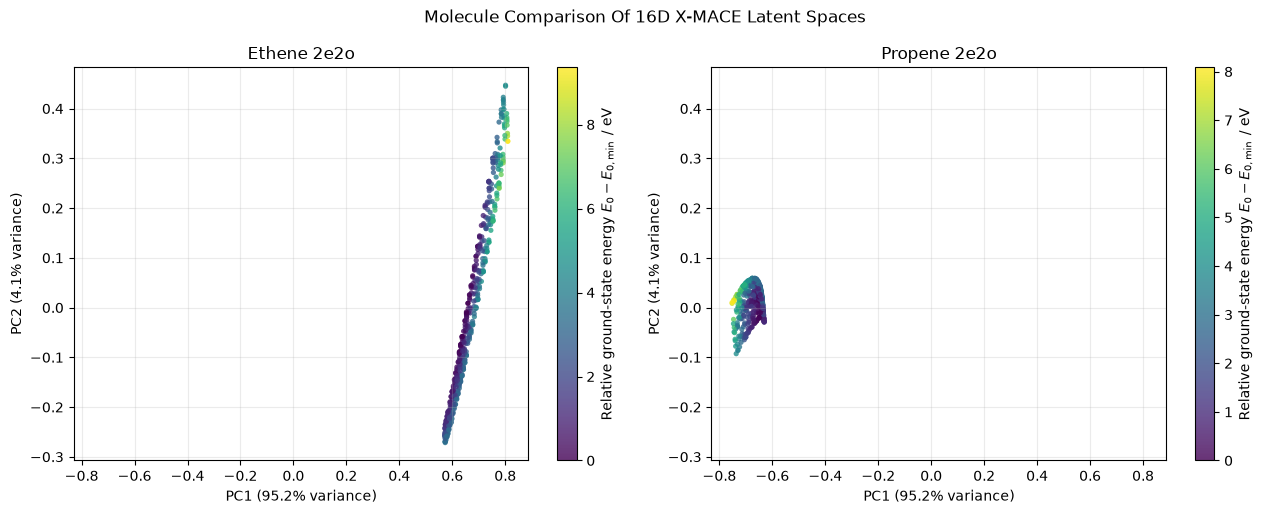

In [20]:
pca_ethene_22, pca_propene_22, variance_molecule = compute_shared_pca_2d(
    latent_ethene_22, latent_propene_22
)

assert pca_ethene_22.shape == (N_GEOMETRIES, 2)
assert pca_propene_22.shape == (N_GEOMETRIES, 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_projected_pca(
    axes[0], pca_ethene_22, atoms_ethene_22, "Ethene 2e2o", variance_molecule
)
plot_projected_pca(
    axes[1], pca_propene_22, atoms_propene_22, "Propene 2e2o", variance_molecule
)
set_shared_pca_limits(axes, pca_ethene_22, pca_propene_22)

fig.suptitle("Molecule Comparison Of 16D X-MACE Latent Spaces")
fig.tight_layout()
fig.savefig(GRAPH_DIR / "pca_molecule_comparison.png", dpi=150)
plt.show()

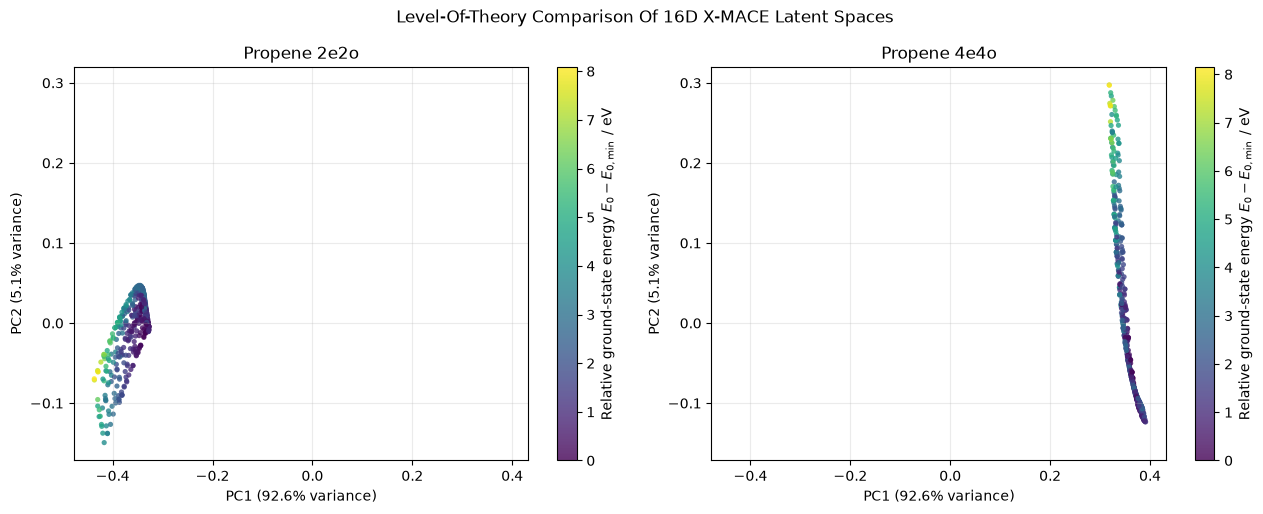

In [21]:
pca_propene_22_theory, pca_propene_44, variance_theory = compute_shared_pca_2d(
    latent_propene_22, latent_propene_44
)

assert pca_propene_22_theory.shape == (N_GEOMETRIES, 2)
assert pca_propene_44.shape == (N_GEOMETRIES, 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_projected_pca(
    axes[0],
    pca_propene_22_theory,
    atoms_propene_22,
    "Propene 2e2o",
    variance_theory,
)
plot_projected_pca(
    axes[1], pca_propene_44, atoms_propene_44, "Propene 4e4o", variance_theory
)
set_shared_pca_limits(axes, pca_propene_22_theory, pca_propene_44)

fig.suptitle("Level-Of-Theory Comparison Of 16D X-MACE Latent Spaces")
fig.tight_layout()
fig.savefig(GRAPH_DIR / "pca_level_of_theory_comparison.png", dpi=150)
plt.show()

Probably those two plots not the most meaningful also because clearly the geometries are in different places but that's also kinda expected? Because the models were trained independently and have no reason to learn the same space. 

However, I think there can probably be some areas to explore this more, ie look at what happens if you first align the two latent spaces first so that we can look at their structure. I think the structural shape of the latent space, how each point is learned relative to each other is what matters. Because the rotations or scalings are probably learned from the decoder. 

Maybe we can find some way to align the two spaces, measure structurally how similar they are, then implement some loss term that helps to guide the transfer learning wrt to the original latent space. Ie if it differs too much from the original latent space and starts drifting away structurally then we know that something is wrong and it should get penalised? Or maybe even guide it away from an exact structural match. 

Eg if the CASPT2 latent space has a certain structure that is maybe 80% similar to the original CASSCF latent space, then we know that by increasing level of theory, we expect latent space structure to change by that much. So at every epoch, we measure the latent space how similar it is to the original trained model's one also, and include a loss term there. 